# Parameter Identification Active Learning

This notebook tests a specific idea:

> Given a pool of literature-generated equation forms with unknown parameters, how quickly can active learning find accurate fitted parameters using only a few RBF fake-lab samples?

The RBF is only a fast stand-in for experiments. The main object being tested is the equation pool and the strategy for choosing the next experiment.

In [1]:
from __future__ import annotations

import inspect
import importlib.util
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from sklearn.metrics import mean_squared_error, r2_score

from active_learning_uncertainty import fit_rbf_truth, random_candidates
from src.config_loader import load_config, resolve_path

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
EQUATION_FILE = ROOT / "output" / "one_shot_literature_equations.py"
OUT_DIR = ROOT / "output" / "parameter_identification_active_learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Equation source: {EQUATION_FILE}")
print(f"Writing outputs to: {OUT_DIR}")

Equation source: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\one_shot_literature_equations.py
Writing outputs to: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\parameter_identification_active_learning


## Settings

The default run repeats every strategy 10 times, compares several pool sizes, and saves full fit histories. Lower `N_CANDIDATES` if you want a faster exploratory run.

In [2]:
RANDOM_STATE = 50
N_REPEATS = 10
SEED_SIZE = 4
ADD_STEPS = 12
N_CANDIDATES = 1200
N_VALIDATION = 1000
RIDGE_ALPHA = 1e-3

POOL_SIZES = [3, 5, 8, "all"]
STRATEGIES = ["random", "max_abs_range", "max_std"]
R2_THRESHOLDS = [0.80, 0.90, 0.95]

# These are parameter-fitting experiments, so observation noise is off by default.
# Add noise later if you want to test robustness.
OBSERVATION_NOISE_STD = 0.0

## Load Data, RBF Fake Lab, and Equation Forms

In [3]:
cfg = load_config()
input_cols = cfg["input_columns"]
output_col = cfg["output_column"]
df = pd.read_excel(resolve_path(cfg, cfg["dataset"]["file"]))
truth = fit_rbf_truth(df, input_cols, output_col)

spec = importlib.util.spec_from_file_location("one_shot_literature_equations", EQUATION_FILE)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

equation_names = list(module.GENERATED_FUNCTIONS)
equations = []
for name in equation_names:
    func = getattr(module, name)
    n_params = len(inspect.signature(func).parameters) - 1
    equations.append({"name": name, "func": func, "n_params": n_params})

print(f"Loaded {len(equations)} equation forms.")
pd.DataFrame({"model": [e["name"] for e in equations], "n_params": [e["n_params"] for e in equations]})

Loaded 12 equation forms.


,model,n_params
0,literature_model_1,4
1,literature_model_2,5
2,literature_model_3,3
3,literature_model_4,4
4,literature_model_5,3
5,literature_model_6,4
6,literature_model_7,5
7,literature_model_8,3
8,literature_model_9,4
9,literature_model_10,4


## Fitting Helpers

Each equation is fit with regularized least-squares. The regularization keeps underdetermined early fits from exploding when there are fewer observations than parameters.

In [4]:
@dataclass
class FittedEquation:
    name: str
    n_params: int
    params: np.ndarray
    train_rmse: float
    train_r2: float
    val_rmse: float
    val_r2: float
    success: bool
    message: str
    func: object


def as_model_input(X_raw: np.ndarray) -> tuple[np.ndarray, ...]:
    return tuple(X_raw[:, i] for i in range(X_raw.shape[1]))


def safe_predict(func, X_raw: np.ndarray, params: np.ndarray) -> np.ndarray:
    try:
        y = np.asarray(func(as_model_input(X_raw), *params), dtype=float).reshape(-1)
        return np.nan_to_num(y, nan=1e9, posinf=1e9, neginf=-1e9)
    except Exception:
        return np.full(X_raw.shape[0], 1e9, dtype=float)


def initial_params(n_params: int, y_obs: np.ndarray) -> np.ndarray:
    params = np.zeros(n_params, dtype=float)
    if n_params:
        params[0] = float(np.mean(y_obs))
    if n_params > 1:
        params[1:] = 0.1
    return params


def fit_one_equation(eq: dict, X_obs: np.ndarray, y_obs: np.ndarray, X_val: np.ndarray, y_val: np.ndarray) -> FittedEquation:
    func = eq["func"]
    n_params = eq["n_params"]
    y_scale = float(np.std(y_obs)) if float(np.std(y_obs)) > 1e-9 else 1.0
    x0 = initial_params(n_params, y_obs)

    def residuals(params: np.ndarray) -> np.ndarray:
        data_residual = (safe_predict(func, X_obs, params) - y_obs) / y_scale
        penalty = np.sqrt(RIDGE_ALPHA) * params
        return np.concatenate([data_residual, penalty])

    try:
        result = least_squares(
            residuals,
            x0,
            loss="soft_l1",
            max_nfev=250,
            x_scale="jac",
        )
        params = result.x
        success = bool(result.success)
        message = str(result.message)
    except Exception as exc:
        params = x0
        success = False
        message = repr(exc)

    train_pred = safe_predict(func, X_obs, params)
    val_pred = safe_predict(func, X_val, params)
    train_rmse = mean_squared_error(y_obs, train_pred) ** 0.5
    val_rmse = mean_squared_error(y_val, val_pred) ** 0.5
    train_r2 = r2_score(y_obs, train_pred) if len(y_obs) > 1 else np.nan
    val_r2 = r2_score(y_val, val_pred)

    return FittedEquation(
        name=eq["name"],
        n_params=n_params,
        params=params,
        train_rmse=train_rmse,
        train_r2=train_r2,
        val_rmse=val_rmse,
        val_r2=val_r2,
        success=success,
        message=message,
        func=func,
    )


def fit_equation_pool(pool: list[dict], X_obs: np.ndarray, y_obs: np.ndarray, X_val: np.ndarray, y_val: np.ndarray) -> list[FittedEquation]:
    fitted = [fit_one_equation(eq, X_obs, y_obs, X_val, y_val) for eq in pool]
    return sorted(fitted, key=lambda model: (-model.val_r2, model.val_rmse))


def predict_fitted_pool(fitted: list[FittedEquation], X_raw: np.ndarray) -> np.ndarray:
    return np.column_stack([safe_predict(model.func, X_raw, model.params) for model in fitted])


def noisy_truth(X_raw: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    y = truth(X_raw)
    if OBSERVATION_NOISE_STD <= 0:
        return y
    return y + rng.normal(0.0, OBSERVATION_NOISE_STD, size=len(y))

## Active Learning Loop

At each step we fit every equation to the currently observed RBF points, evaluate every fit on a clean validation set, and pick the next point by random sampling, maximum prediction range, or maximum prediction standard deviation.

In [5]:
def choose_next_candidate(strategy: str, fitted: list[FittedEquation], X_candidates: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, dict]:
    predictions = predict_fitted_pool(fitted, X_candidates)
    pred_range = predictions.max(axis=1) - predictions.min(axis=1)
    pred_std = predictions.std(axis=1)

    if strategy == "random":
        scores = rng.random(len(X_candidates))
    elif strategy == "max_abs_range":
        scores = np.abs(pred_range)
    elif strategy == "max_std":
        scores = pred_std
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    index = int(np.argmax(scores))
    info = {
        "candidate_score": float(scores[index]),
        "candidate_prediction_range": float(pred_range[index]),
        "candidate_prediction_std": float(pred_std[index]),
        "candidate_prediction_mean": float(predictions[index].mean()),
    }
    return X_candidates[index], info


def run_one_parameter_id_trace(pool: list[dict], pool_label: str, strategy: str, repeat_index: int, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    X_obs = random_candidates(truth.input_bounds, SEED_SIZE, rng)
    y_obs = noisy_truth(X_obs, rng)
    X_val = random_candidates(truth.input_bounds, N_VALIDATION, rng)
    y_val = truth(X_val)

    fit_rows = []
    best_rows = []

    for step in range(ADD_STEPS + 1):
        fitted = fit_equation_pool(pool, X_obs, y_obs, X_val, y_val)
        best = fitted[0]

        for rank, model in enumerate(fitted, start=1):
            fit_rows.append(
                {
                    "pool_label": pool_label,
                    "pool_size": len(pool),
                    "strategy": strategy,
                    "repeat": repeat_index,
                    "seed": seed,
                    "step": step,
                    "n_observed": len(X_obs),
                    "rank": rank,
                    "model": model.name,
                    "n_params": model.n_params,
                    "params": ", ".join(f"{value:.8g}" for value in model.params),
                    "train_rmse": model.train_rmse,
                    "train_r2": model.train_r2,
                    "val_rmse": model.val_rmse,
                    "val_r2": model.val_r2,
                    "success": model.success,
                    "message": model.message,
                    "is_best": rank == 1,
                }
            )

        best_rows.append(
            {
                "pool_label": pool_label,
                "pool_size": len(pool),
                "strategy": strategy,
                "repeat": repeat_index,
                "seed": seed,
                "step": step,
                "n_observed": len(X_obs),
                "best_model": best.name,
                "best_n_params": best.n_params,
                "best_params": ", ".join(f"{value:.8g}" for value in best.params),
                "best_train_rmse": best.train_rmse,
                "best_train_r2": best.train_r2,
                "best_val_rmse": best.val_rmse,
                "best_val_r2": best.val_r2,
            }
        )

        if step == ADD_STEPS:
            break

        X_candidates = random_candidates(truth.input_bounds, N_CANDIDATES, rng)
        next_x, info = choose_next_candidate(strategy, fitted, X_candidates, rng)
        next_y = noisy_truth(next_x.reshape(1, -1), rng)[0]

        best_rows[-1].update({f"next_{col}": next_x[i] for i, col in enumerate(input_cols)})
        best_rows[-1].update(info)

        X_obs = np.vstack([X_obs, next_x])
        y_obs = np.append(y_obs, next_y)

    return pd.DataFrame(fit_rows), pd.DataFrame(best_rows)


def make_pool(size_or_all) -> tuple[str, list[dict]]:
    if size_or_all == "all":
        return "all_12", equations
    size = int(size_or_all)
    return f"top_{size}", equations[:size]

## Run Experiment

This is the slow cell. It writes three CSVs and one detailed text report when finished.

In [6]:
all_fit_rows = []
all_best_rows = []

for pool_setting in POOL_SIZES:
    pool_label, pool = make_pool(pool_setting)
    print(f"Running pool {pool_label} with {len(pool)} models...")
    for strategy in STRATEGIES:
        for repeat in range(N_REPEATS):
            seed = RANDOM_STATE + 1000 * len(pool) + 100 * STRATEGIES.index(strategy) + repeat
            fit_trace, best_trace = run_one_parameter_id_trace(pool, pool_label, strategy, repeat, seed)
            all_fit_rows.append(fit_trace)
            all_best_rows.append(best_trace)

fit_history = pd.concat(all_fit_rows, ignore_index=True)
best_history = pd.concat(all_best_rows, ignore_index=True)

fit_history_path = OUT_DIR / "model_fit_history.csv"
best_history_path = OUT_DIR / "best_model_history.csv"
fit_history.to_csv(fit_history_path, index=False)
best_history.to_csv(best_history_path, index=False)

print(f"Wrote: {fit_history_path}")
print(f"Wrote: {best_history_path}")
best_history.head()

Running pool top_3 with 3 models...
Running pool top_5 with 5 models...
Running pool top_8 with 8 models...
Running pool all_12 with 12 models...
Wrote: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\parameter_identification_active_learning\model_fit_history.csv
Wrote: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\parameter_identification_active_learning\best_model_history.csv


,pool_label,pool_size,strategy,repeat,seed,step,n_observed,best_model,best_n_params,best_params,...,best_val_rmse,best_val_r2,next_WaterSpeed (m/s),next_PulseEnergy (microJ),next_Frequency (kHz),next_ScanningSpeed (mm/s),candidate_score,candidate_prediction_range,candidate_prediction_std,candidate_prediction_mean
0,top_3,3,random,0,3050,0,4,literature_model_1,4,"-0.96160355, -3.5274491, 1.4997323, 2.7798439",...,6.800189,0.799658,6.762950,17.029525,7.983615,4.655072,0.997771,12.239885,5.210350,17.839121
1,top_3,3,random,0,3050,1,5,literature_model_1,4,"-1.3628711, -2.8473085, 0.99054447, 4.13257",...,11.359674,0.440934,6.710262,13.062386,12.486760,2.943423,0.999594,34.159570,16.031900,32.888093
2,top_3,3,random,0,3050,2,6,literature_model_2,5,"-1.1808208, -3.5352311, 1.3670182, 2.9605086, ...",...,6.486876,0.817693,7.466486,10.132951,15.518309,3.248801,0.997184,23.390109,10.878228,25.568627
3,top_3,3,random,0,3050,3,7,literature_model_2,5,"-0.79789042, -3.5815293, 1.4476801, 2.8124289,...",...,6.547419,0.814275,7.952464,16.953843,7.490082,8.686104,0.999522,7.642194,3.458204,20.929097
4,top_3,3,random,0,3050,4,8,literature_model_1,4,"-6.7769756, -2.0559251, 1.4473799, 2.5972065",...,6.170456,0.835045,7.495307,19.109825,17.056323,2.023427,0.999011,21.230543,9.368107,41.669771


## Text Report

The report contains each model's fitted parameter vector at every step, its train/validation metrics, and the best equation at each step.

In [7]:
report_path = OUT_DIR / "parameter_identification_fit_report.txt"

with report_path.open("w", encoding="utf-8") as f:
    f.write("Parameter Identification Active Learning Report\n")
    f.write("=" * 72 + "\n\n")
    f.write(f"Equation file: {EQUATION_FILE}\n")
    f.write(f"Pool sizes: {POOL_SIZES}\n")
    f.write(f"Strategies: {STRATEGIES}\n")
    f.write(f"Repeats per setting: {N_REPEATS}\n")
    f.write(f"Seed size: {SEED_SIZE}; add steps: {ADD_STEPS}\n")
    f.write(f"Candidates per step: {N_CANDIDATES}; validation samples: {N_VALIDATION}\n")
    f.write(f"Observation noise std: {OBSERVATION_NOISE_STD}\n\n")

    f.write("Best equation at each step\n")
    f.write("-" * 72 + "\n")
    for row in best_history.sort_values(["pool_size", "strategy", "repeat", "step"]).itertuples(index=False):
        f.write(
            f"pool={row.pool_label} strategy={row.strategy} repeat={row.repeat} "
            f"step={row.step} n={row.n_observed} best={row.best_model} "
            f"R2={row.best_val_r2:.6f} RMSE={row.best_val_rmse:.6f} "
            f"params=[{row.best_params}]\n"
        )

    f.write("\n\nFull model fits at each step\n")
    f.write("-" * 72 + "\n")
    for row in fit_history.sort_values(["pool_size", "strategy", "repeat", "step", "rank"]).itertuples(index=False):
        f.write(
            f"pool={row.pool_label} strategy={row.strategy} repeat={row.repeat} "
            f"step={row.step} n={row.n_observed} rank={row.rank} model={row.model} "
            f"train_R2={row.train_r2:.6f} train_RMSE={row.train_rmse:.6f} "
            f"val_R2={row.val_r2:.6f} val_RMSE={row.val_rmse:.6f} "
            f"params=[{row.params}] success={row.success}\n"
        )

print(f"Wrote: {report_path}")
report_path

Wrote: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\parameter_identification_active_learning\parameter_identification_fit_report.txt


WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/parameter_identification_active_learning/parameter_identification_fit_report.txt')

## Summaries and Plots

In [8]:
summary = (
    best_history.groupby(["pool_label", "pool_size", "strategy", "n_observed"], as_index=False)
    .agg(
        r2_mean=("best_val_r2", "mean"),
        r2_std=("best_val_r2", "std"),
        rmse_mean=("best_val_rmse", "mean"),
        rmse_std=("best_val_rmse", "std"),
    )
    .fillna(0.0)
)

final_summary = summary[summary["n_observed"] == SEED_SIZE + ADD_STEPS].sort_values(
    ["pool_size", "r2_mean"], ascending=[True, False]
)
summary.to_csv(OUT_DIR / "learning_curve_summary.csv", index=False)
final_summary.to_csv(OUT_DIR / "final_strategy_summary.csv", index=False)
final_summary

,pool_label,pool_size,strategy,n_observed,r2_mean,r2_std,rmse_mean,rmse_std
77,top_3,3,random,16,0.856003,0.020751,5.783293,0.410348
51,top_3,3,max_abs_range,16,0.660090,0.048245,9.049052,0.637024
64,top_3,3,max_std,16,0.569221,0.098982,10.024905,1.274106
116,top_5,5,random,16,0.834307,0.038706,6.273920,0.630797
103,top_5,5,max_std,16,0.702071,0.026621,8.299181,0.365705
90,top_5,5,max_abs_range,16,0.670326,0.034882,8.777148,0.505912
155,top_8,8,random,16,0.842107,0.029063,6.088107,0.524765
129,top_8,8,max_abs_range,16,0.673657,0.055487,8.736543,0.683408
142,top_8,8,max_std,16,0.668056,0.054715,8.816700,0.762457
38,all_12,12,random,16,0.838393,0.025098,6.151998,0.427778


WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/parameter_identification_active_learning/best_model_learning_curves_by_pool.png')

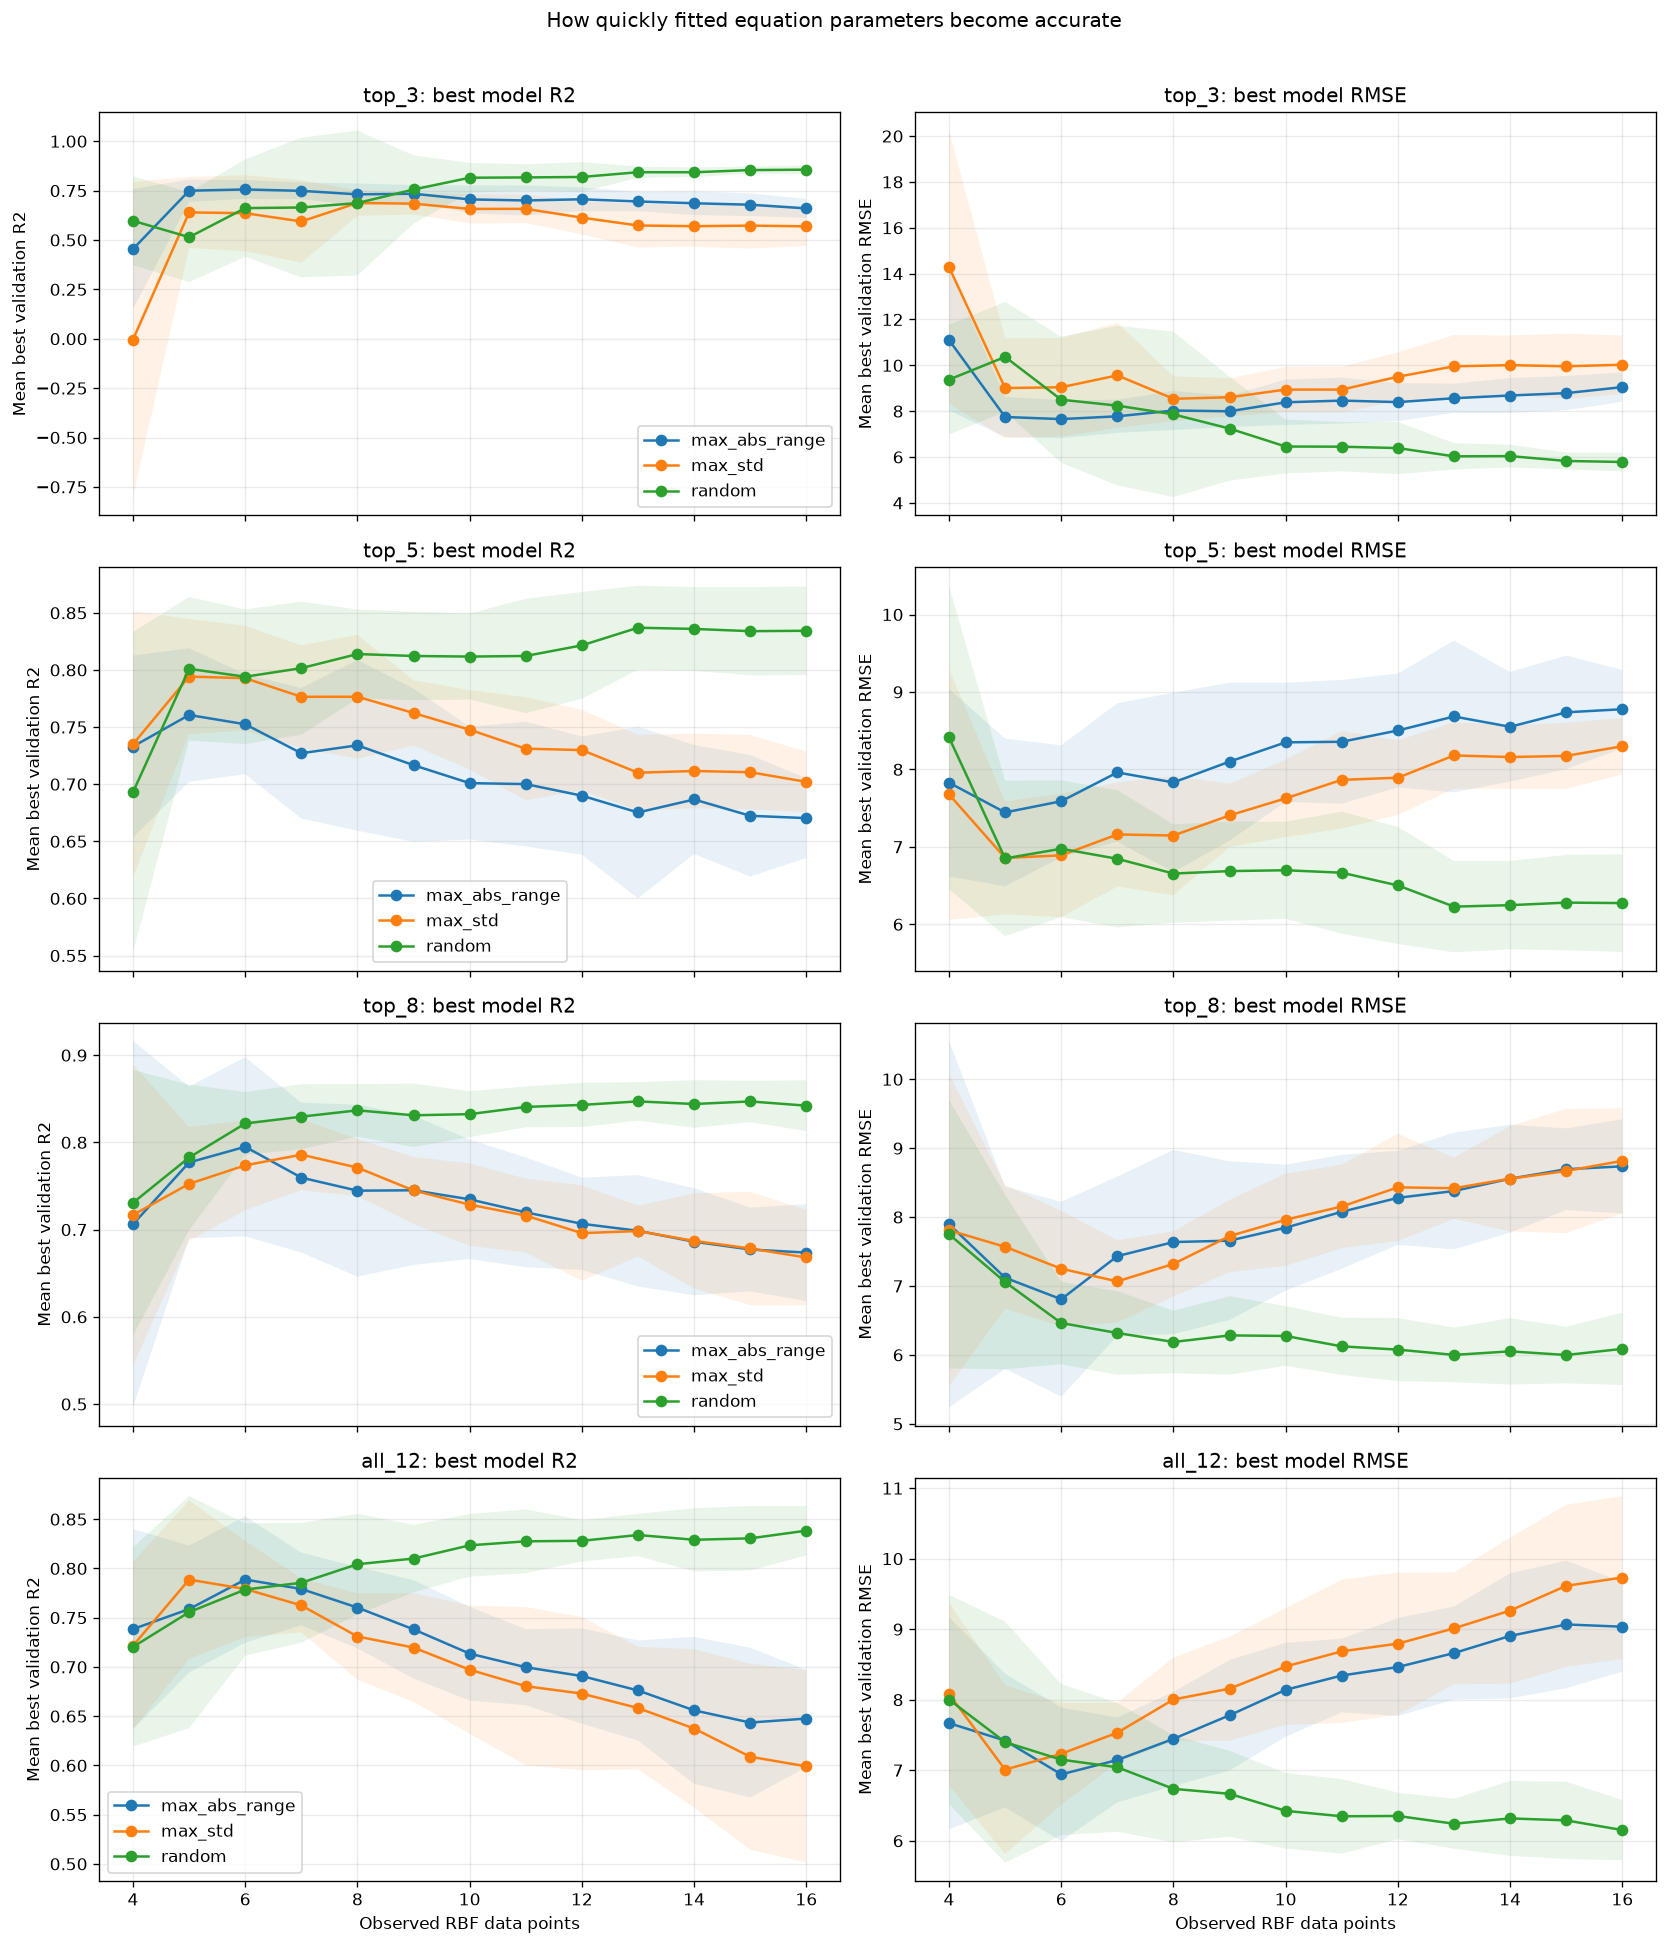

In [9]:
fig, axes = plt.subplots(len(POOL_SIZES), 2, figsize=(14, 4 * len(POOL_SIZES)), sharex=True)

for row_idx, pool_setting in enumerate(POOL_SIZES):
    pool_label, _ = make_pool(pool_setting)
    frame = summary[summary["pool_label"] == pool_label]
    for strategy, group in frame.groupby("strategy"):
        group = group.sort_values("n_observed")
        axes[row_idx, 0].plot(group["n_observed"], group["r2_mean"], marker="o", label=strategy)
        axes[row_idx, 0].fill_between(group["n_observed"], group["r2_mean"] - group["r2_std"], group["r2_mean"] + group["r2_std"], alpha=0.10)
        axes[row_idx, 1].plot(group["n_observed"], group["rmse_mean"], marker="o", label=strategy)
        axes[row_idx, 1].fill_between(group["n_observed"], group["rmse_mean"] - group["rmse_std"], group["rmse_mean"] + group["rmse_std"], alpha=0.10)

    axes[row_idx, 0].set_title(f"{pool_label}: best model R2")
    axes[row_idx, 1].set_title(f"{pool_label}: best model RMSE")
    axes[row_idx, 0].set_ylabel("Mean best validation R2")
    axes[row_idx, 1].set_ylabel("Mean best validation RMSE")
    axes[row_idx, 0].legend(loc="best")

axes[-1, 0].set_xlabel("Observed RBF data points")
axes[-1, 1].set_xlabel("Observed RBF data points")
fig.suptitle("How quickly fitted equation parameters become accurate", y=1.01)
fig.tight_layout()
learning_plot_path = OUT_DIR / "best_model_learning_curves_by_pool.png"
fig.savefig(learning_plot_path, dpi=180)
learning_plot_path

WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/parameter_identification_active_learning/final_metrics_by_pool_size.png')

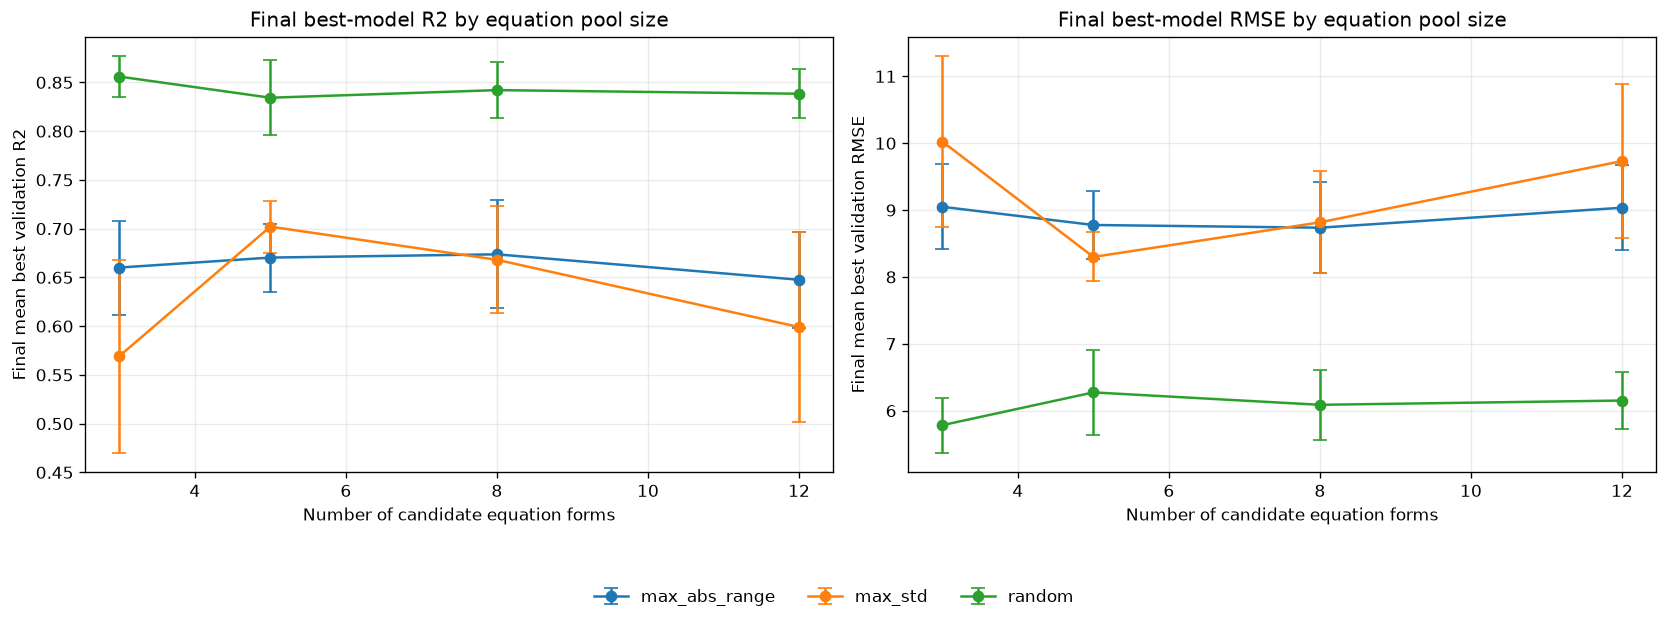

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

for strategy, group in final_summary.groupby("strategy"):
    group = group.sort_values("pool_size")
    axes[0].errorbar(group["pool_size"], group["r2_mean"], yerr=group["r2_std"], marker="o", capsize=4, label=strategy)
    axes[1].errorbar(group["pool_size"], group["rmse_mean"], yerr=group["rmse_std"], marker="o", capsize=4, label=strategy)

axes[0].set_title("Final best-model R2 by equation pool size")
axes[0].set_xlabel("Number of candidate equation forms")
axes[0].set_ylabel("Final mean best validation R2")
axes[1].set_title("Final best-model RMSE by equation pool size")
axes[1].set_xlabel("Number of candidate equation forms")
axes[1].set_ylabel("Final mean best validation RMSE")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.12, 1, 1))
final_plot_path = OUT_DIR / "final_metrics_by_pool_size.png"
fig.savefig(final_plot_path, dpi=180)
final_plot_path

,threshold,pool_label,pool_size,strategy,points_needed_mean,success_rate
0,0.80,all_12,12,max_abs_range,5.285714,0.7
1,0.80,all_12,12,max_std,4.875000,0.8
2,0.80,all_12,12,random,6.600000,1.0
3,0.80,top_3,3,max_abs_range,5.666667,0.3
4,0.80,top_3,3,max_std,5.500000,0.2
5,0.80,top_3,3,random,8.300000,1.0
6,0.80,top_5,5,max_abs_range,5.000000,0.6
7,0.80,top_5,5,max_std,4.666667,0.9
8,0.80,top_5,5,random,5.500000,1.0
9,0.80,top_8,8,max_abs_range,4.777778,0.9


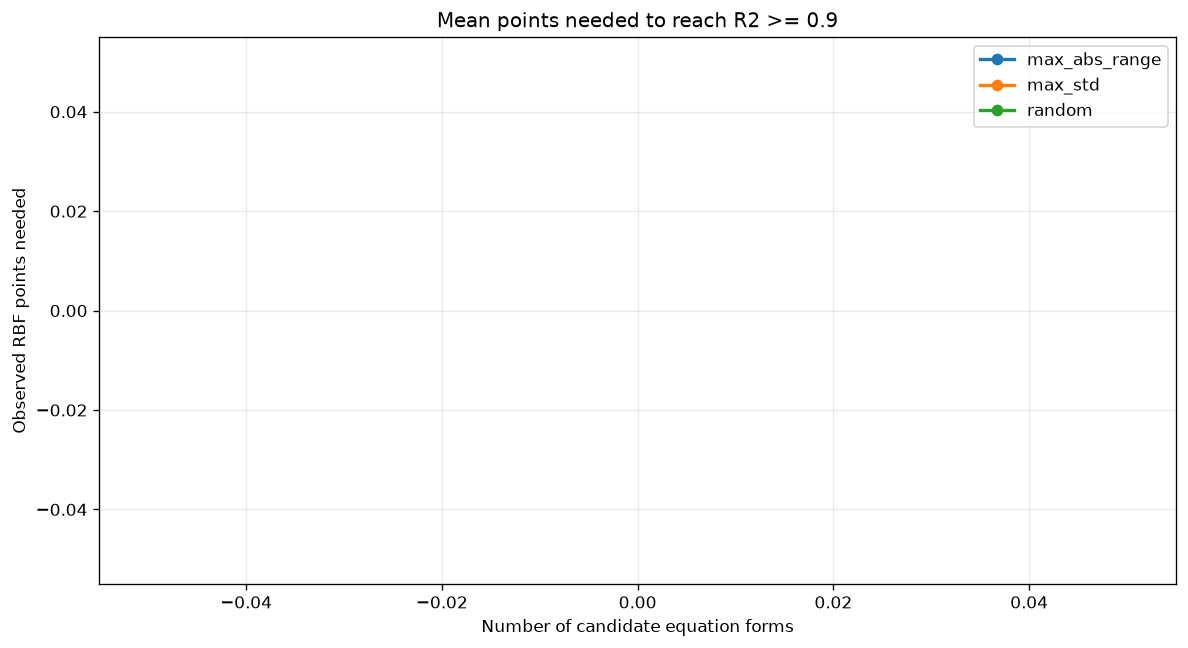

In [11]:
threshold_rows = []
for threshold in R2_THRESHOLDS:
    for (pool_label, pool_size, strategy, repeat), group in best_history.groupby(["pool_label", "pool_size", "strategy", "repeat"]):
        hit = group[group["best_val_r2"] >= threshold].sort_values("n_observed")
        threshold_rows.append(
            {
                "threshold": threshold,
                "pool_label": pool_label,
                "pool_size": pool_size,
                "strategy": strategy,
                "repeat": repeat,
                "points_needed": float(hit["n_observed"].iloc[0]) if len(hit) else np.nan,
            }
        )

threshold_history = pd.DataFrame(threshold_rows)
threshold_summary = (
    threshold_history.groupby(["threshold", "pool_label", "pool_size", "strategy"], as_index=False)
    .agg(points_needed_mean=("points_needed", "mean"), success_rate=("points_needed", lambda values: values.notna().mean()))
)
threshold_history.to_csv(OUT_DIR / "points_to_r2_threshold_history.csv", index=False)
threshold_summary.to_csv(OUT_DIR / "points_to_r2_threshold_summary.csv", index=False)

threshold_to_plot = 0.90
plot_frame = threshold_summary[threshold_summary["threshold"] == threshold_to_plot]
fig, ax = plt.subplots(figsize=(10, 5.5))
for strategy, group in plot_frame.groupby("strategy"):
    group = group.sort_values("pool_size")
    ax.plot(group["pool_size"], group["points_needed_mean"], marker="o", linewidth=2, label=strategy)
ax.set_title(f"Mean points needed to reach R2 >= {threshold_to_plot}")
ax.set_xlabel("Number of candidate equation forms")
ax.set_ylabel("Observed RBF points needed")
ax.legend(loc="best")
fig.tight_layout()
threshold_plot_path = OUT_DIR / "points_needed_to_r2_090.png"
fig.savefig(threshold_plot_path, dpi=180)
threshold_summary